### `Import dependencies`

In [1]:
import os, re, math, tqdm
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from ultralytics import YOLO
from flask import Flask, Response
from gfpgan import GFPGANer
import mediapipe as mp
import shutil
from deepface import DeepFace

/home/dsoft/miniconda3/envs/retail/lib/python3.10/site-packages/torchvision/transforms/functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
QUALIFIED_DIR = "face_padding_roi_clahe_restore"
ORIGIN_FOLDER = "face_padding_roi"
IMG_PER_ROW = 5 # so cap anh moi hang

In [3]:
selected_files = [
    "face_id13_1500.jpg", "face_id13_1510.jpg",
    "face_id1_620.jpg", "face_id1_660.jpg",
    "face_id26_2500.jpg", "face_id26_2520.jpg",
    "face_id2_230.jpg", "face_id2_220.jpg",
    "face_id39_4380.jpg", "face_id39_4420.jpg",
    "face_id44_4440.jpg", "face_id44_4450.jpg",
    "face_id46_4510.jpg",
    "face_id47_4540.jpg", "face_id47_4550.jpg",
]
common_files = [
    f for f in selected_files
    if os.path.exists(os.path.join(ORIGIN_FOLDER, f))
    and os.path.exists(os.path.join(QUALIFIED_DIR, f))
]


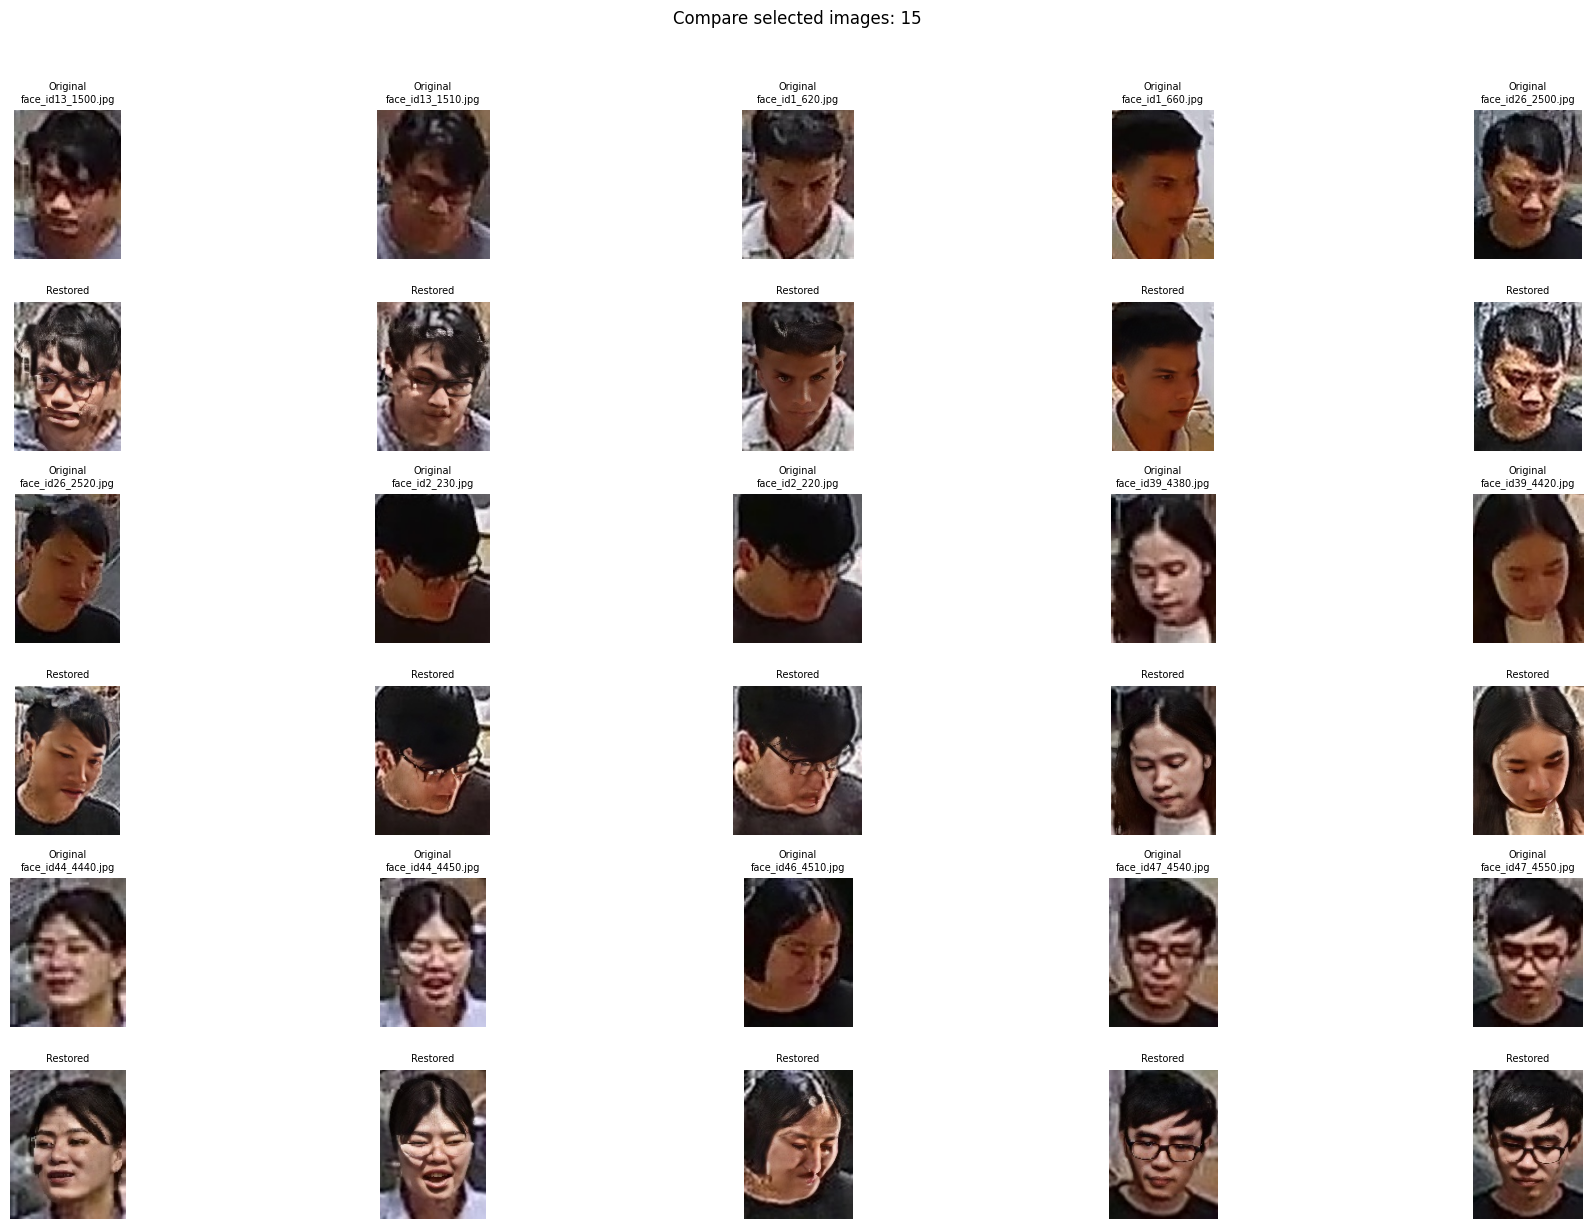

In [4]:
if not common_files:
    print("Không tìm thấy ảnh tương ứng giữa 2 thư mục.")
else:
    n_pairs = len(common_files)
    n_rows = math.ceil(n_pairs / IMG_PER_ROW)

    plt.figure(figsize=(4*IMG_PER_ROW, 4*n_rows))
    for idx, fname in enumerate(common_files):
        img_ori = cv2.imread(os.path.join(ORIGIN_FOLDER, fname))
        img_new = cv2.imread(os.path.join(QUALIFIED_DIR, fname))
        if img_ori is None or img_new is None:
            continue

        img_ori = cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB)
        img_new = cv2.cvtColor(img_new, cv2.COLOR_BGR2RGB)

        # Ảnh gốc (hàng trên)
        plt.subplot(n_rows * 2, IMG_PER_ROW, idx + 1 + (idx // IMG_PER_ROW) * IMG_PER_ROW)
        plt.imshow(img_ori)
        plt.title(f"Original\n{fname}", fontsize=7)
        plt.axis("off")

        # Ảnh xử lý (hàng dưới)
        plt.subplot(n_rows * 2, IMG_PER_ROW, idx + 1 + (idx // IMG_PER_ROW) * IMG_PER_ROW + IMG_PER_ROW)
        plt.imshow(img_new)
        plt.title("Restored", fontsize=7)
        plt.axis("off")

    plt.suptitle(f"Compare selected images: {n_pairs}", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()